1. Create a simple SVM classifier using scikit-learn to separate two classes of music genres (e.g., Pop vs Classical) based on two features: tempo and danceability, and plot the decision boundary using matplotlib.


c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


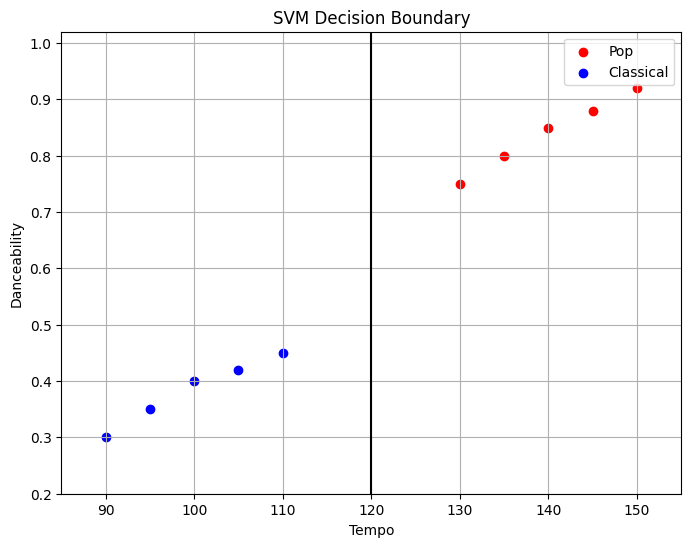

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC

music = pd.DataFrame({
    "tempo":[90,95,100,105,110,130,135,140,145,150],
    "danceability":[0.30,0.35,0.40,0.42,0.45,
                    0.75,0.80,0.85,0.88,0.92],
    "genre":["Classical","Classical","Classical","Classical","Classical",
             "Pop","Pop","Pop","Pop","Pop"]
})

X = music[["tempo","danceability"]]
y = music["genre"]

model = SVC(kernel="linear")
model.fit(X, y)

plt.figure(figsize=(8,6))

colors = {"Pop":"red", "Classical":"blue"}

for label in colors:
    subset = music[music["genre"] == label]
    plt.scatter(
        subset["tempo"],
        subset["danceability"],
        c=colors[label],
        label=label
    )

x_min, x_max = X["tempo"].min()-5, X["tempo"].max()+5
y_min, y_max = X["danceability"].min()-0.1, X["danceability"].max()+0.1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = np.where(Z == "Pop", 1, 0)
Z = Z.reshape(xx.shape)

plt.contour(xx, yy, Z, levels=[0.5], colors="black")

plt.xlabel("Tempo")
plt.ylabel("Danceability")
plt.title("SVM Decision Boundary")
plt.legend()
plt.grid(True)
plt.show()

2. Given a dataset of Flipkart product reviews labeled as positive or negative, use an SVM with a linear kernel to classify the reviews and print the accuracy score.


In [2]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

reviews = pd.DataFrame({
    "review":[
        "Excellent product",
        "Very bad quality",
        "Loved it",
        "Waste of money",
        "Amazing phone",
        "Poor battery",
        "Highly recommended",
        "Terrible experience",
        "Best purchase",
        "Not worth buying"
    ],
    "label":[
        "positive","negative","positive","negative",
        "positive","negative","positive","negative",
        "positive","negative"
    ]
})

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(reviews["review"])
y = reviews["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

svm = SVC(kernel="linear")

svm.fit(X_train, y_train)

pred = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.3333333333333333


3. Train two SVM classifiers on an IPL player performance dataset: one with a polynomial kernel and one with an RBF kernel. Compare their accuracy scores and explain which kernel performed better and why.<br><br><em><strong>Hint:</strong> Use scikit-learn's SVC class and the 'kernel' parameter.</em>


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

ipl = pd.DataFrame({
    "runs":[300,450,600,250,700,150,550,650,200,500],
    "wickets":[5,2,1,8,0,10,2,1,9,3],
    "strike_rate":[120,135,150,110,160,95,145,155,100,140],
    "star":[0,1,1,0,1,0,1,1,0,1]
})

X = ipl[["runs","wickets","strike_rate"]]
y = ipl["star"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)
poly = SVC(kernel="poly", degree=3)
poly.fit(X_train, y_train)
poly_pred = poly.predict(X_test)

rbf = SVC(kernel="rbf")
rbf.fit(X_train, y_train)
rbf_pred = rbf.predict(X_test)

print("Polynomial Accuracy:",
      accuracy_score(y_test, poly_pred))

print("RBF Accuracy:",
      accuracy_score(y_test, rbf_pred))

Polynomial Accuracy: 1.0
RBF Accuracy: 1.0


4. Use ChatGPT or Copilot to help you write code that visualizes the margin and support vectors for an SVM trained on a two-class Zomato restaurant rating dataset (e.g., 'Good' vs 'Bad' ratings). Paste your code and a screenshot of the plot.

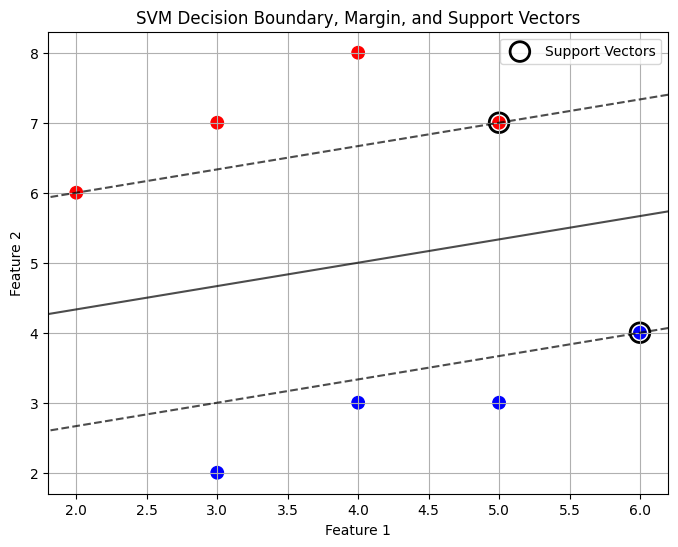

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

X = np.array([
    [3,2],
    [4,3],
    [5,3],
    [6,4],
    [2,6],
    [3,7],
    [4,8],
    [5,7]
])

y = np.array([0,0,0,0,1,1,1,1])

model = SVC(kernel="linear", C=1)

model.fit(X, y)

plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap="bwr",
    s=80
)

plt.scatter(
    model.support_vectors_[:,0],
    model.support_vectors_[:,1],
    s=200,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="Support Vectors"
)

ax = plt.gca()

xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)

YY, XX = np.meshgrid(yy, xx)

xy = np.vstack([XX.ravel(), YY.ravel()]).T

Z = model.decision_function(xy).reshape(XX.shape)

ax.contour(
    XX,
    YY,
    Z,
    colors="k",
    levels=[-1,0,1],
    alpha=0.7,
    linestyles=["--","-","--"]
)

plt.title("SVM Decision Boundary, Margin, and Support Vectors")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()